In [2]:
import sys
!{sys.executable} -m pip install pyswarms deap keras-tcn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

import pyswarms as ps

from deap import base, creator, tools, algorithms
import random

np.random.seed(42)
random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [4]:
data_path = Path("cleandata.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "cleandata.csv was not found. Put it in the same folder as this notebook before running."
    )

df = pd.read_csv(data_path)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

series = df['demand_kWh']
series = series.asfreq('h')
series = series.ffill()


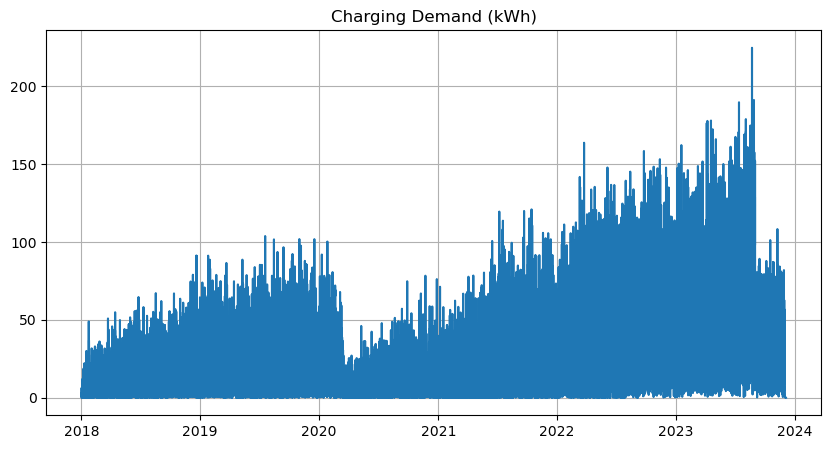

In [5]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Charging Demand (kWh)")
plt.grid()
plt.show()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [6]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(0,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

sarima_fit = sarima_model.fit(disp=False, low_memory=True)
sarima_pred = sarima_fit.forecast(steps=len(test))

In [7]:
# SCALING + SEQUENCES
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(scaled, window)

X_train, X_test = X[:train_size-window], X[train_size-window:]
y_train, y_test = y[:train_size-window], y[train_size-window:]

y_test_inv = scaler.inverse_transform(y_test)

In [8]:
# TCN MODEL
def sanitize_tcn_params(filters=64, kernel_size=3, dropout=0.2):
    filters = int(np.clip(round(filters), 32, 128))
    kernel_size = int(np.clip(round(kernel_size), 2, 5))
    dropout = float(np.clip(dropout, 0.1, 0.5))
    return filters, kernel_size, dropout

def build_tcn(filters=64, kernel_size=3, dropout=0.2):
    filters, kernel_size, dropout = sanitize_tcn_params(filters, kernel_size, dropout)

    model = Sequential([
        TCN(filters, kernel_size=kernel_size, dropout_rate=dropout, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

tf.keras.backend.clear_session()
tcn_model = build_tcn()
tcn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1, shuffle=False)
tcn_pred = scaler.inverse_transform(tcn_model.predict(X_test, verbose=0))


2026-04-26 12:03:31,199 - tensorflow - WARNING - From C:\Users\ASUS TUF-Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.



Epoch 1/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 2/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - loss: 0.0015 - val_loss: 0.0035
Epoch 3/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 4/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 5/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 6/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - loss: 0.0014 - val_loss: 0.0032
Epoch 7/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - loss: 0.0013 - val_loss: 0.0036
Epoch 8/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - loss: 0.0013 - val_loss: 0.0034
Epoch 9/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - loss: 0.0013 - val_loss: 0.0035
Epoch 10/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - loss: 0.0013 - val_loss: 0.0034


In [9]:
# PSO OPTIMIZATION
best_cost = 170.89077222929302
best_pos = np.array([96.52501255, 4.28485885, 0.19505502])

best_filters, best_kernel, best_dropout = sanitize_tcn_params(best_pos[0], best_pos[1], best_pos[2])
print("PSO Best Hyperparameters:", best_pos)
tf.keras.backend.clear_session()
pso_model = build_tcn(best_filters, best_kernel, best_dropout)
pso_model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1, shuffle=False)
pso_pred = scaler.inverse_transform(pso_model.predict(X_test, verbose=0))


PSO Best Hyperparameters: [96.52501255  4.28485885  0.19505502]
Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 67s 64ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 69s 66ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 69s 66ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 68s 66ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 59s 57ms/step - loss: 0.0013 - val_loss: 0.0034
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 70s 67ms/step - loss: 0.0013 - val_loss: 0.0035
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 69s 66ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━

In [10]:
# GA OPTIMIZATION
if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def clean_individual(ind):
    filters, kernel_size, dropout = sanitize_tcn_params(ind[0], ind[1], ind[2])
    ind[0], ind[1], ind[2] = filters, kernel_size, dropout
    return ind

def eval_individual(ind):
    clean_individual(ind)
    tf.keras.backend.clear_session()
    model = build_tcn(ind[0], ind[1], ind[2])
    model.fit(X_train, y_train, epochs=5, verbose=0, shuffle=False)

    pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
    return (float(np.mean((pred - y_test_inv) ** 2)),)

toolbox = base.Toolbox()
toolbox.register("attr_filters", random.randint, 32, 128)
toolbox.register("attr_kernel", random.randint, 2, 5)
toolbox.register("attr_dropout", random.uniform, 0.1, 0.5)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.attr_filters, toolbox.attr_kernel, toolbox.attr_dropout),
    n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", eval_individual)

def mate_individuals(ind1, ind2):
    tools.cxBlend(ind1, ind2, alpha=0.5)
    clean_individual(ind1)
    clean_individual(ind2)
    return ind1, ind2

def mutate_individual(ind):
    ind[0] = ind[0] + random.randint(-10, 10)
    ind[1] = ind[1] + random.randint(-1, 1)
    ind[2] = ind[2] + random.uniform(-0.1, 0.1)
    clean_individual(ind)
    return (ind,)

toolbox.register("mate", mate_individuals)
toolbox.register("mutate", mutate_individual)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
pop, _ = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=True)

best_ind = clean_individual(tools.selBest(pop, 1)[0])
print("GA Best Hyperparameters:", best_ind)

tf.keras.backend.clear_session()
ga_model = build_tcn(best_ind[0], best_ind[1], best_ind[2])
ga_model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1, shuffle=False)
ga_pred = scaler.inverse_transform(ga_model.predict(X_test, verbose=0))


gen	nevals
0  	5     
1  	3     
2  	2     
3  	4     
4  	2     
5  	3     
GA Best Hyperparameters: [125, 5, 0.3144912365818803]
Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 108s 88ms/step - loss: 0.0022 - val_loss: 0.0043
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 88s 85ms/step - loss: 0.0015 - val_loss: 0.0039
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 85s 81ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 87s 84ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 95s 92ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 88s 84ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 89s 86ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 88s 84ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 89s 86ms/step -

In [11]:
def metrics(actual, pred):
    actual = np.array(actual).flatten()
    pred = np.array(pred).flatten()
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    mape = np.mean(np.abs((actual - pred) / np.where(actual==0, 1e-8, actual))) * 100
    
    smape = np.mean(
        np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred)) / 2 + 1e-8)
    ) * 100
    
    r2 = r2_score(actual, pred)
    
    return mae, rmse, mape, smape, r2

In [12]:
# EVALUATION
m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv, tcn_pred)
m_pso = metrics(y_test_inv, pso_pred)
m_ga = metrics(y_test_inv, ga_pred)

In [13]:
results_df = pd.DataFrame({
    'Model': ['SARIMA', 'TCN', 'PSO-TCN', 'GA-TCN'],
    'MAE': [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]],
    'RMSE': [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]],
    'MAPE (%)': [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]],
    'SMAPE (%)': [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]],
    'R2': [m_sarima[4], m_tcn[4], m_pso[4], m_ga[4]],
})

print("\nMODEL PERFORMANCE COMPARISON:\n")
print(results_df)


MODEL PERFORMANCE COMPARISON:

     Model        MAE       RMSE    MAPE (%)   SMAPE (%)        R2
0   SARIMA  46.005234  58.964192  100.026059  199.921230 -1.556093
1      TCN  10.548706  15.755059   65.090044   29.777286  0.817510
2  PSO-TCN  10.109255  15.243844   52.826054   27.536376  0.829160
3   GA-TCN  10.005014  14.786424   60.128769   28.550111  0.839259


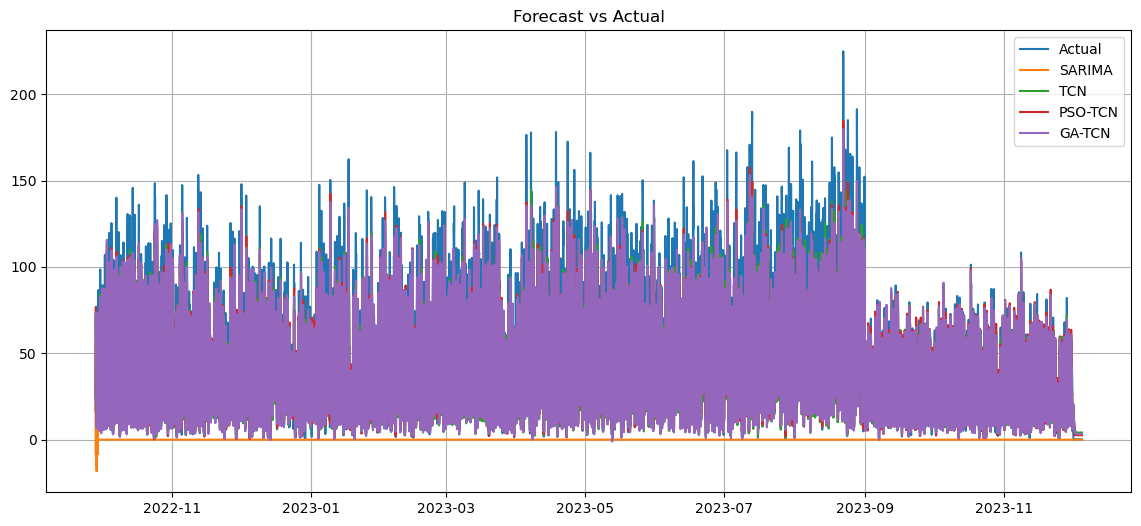

In [14]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, sarima_pred.values, label='SARIMA')
plt.plot(test.index[-len(tcn_pred):], tcn_pred.flatten(), label='TCN')
plt.plot(test.index[-len(pso_pred):], pso_pred.flatten(), label='PSO-TCN')
plt.plot(test.index[-len(ga_pred):], ga_pred.flatten(), label='GA-TCN')
plt.legend()
plt.title("Forecast vs Actual")
plt.grid()
plt.show()


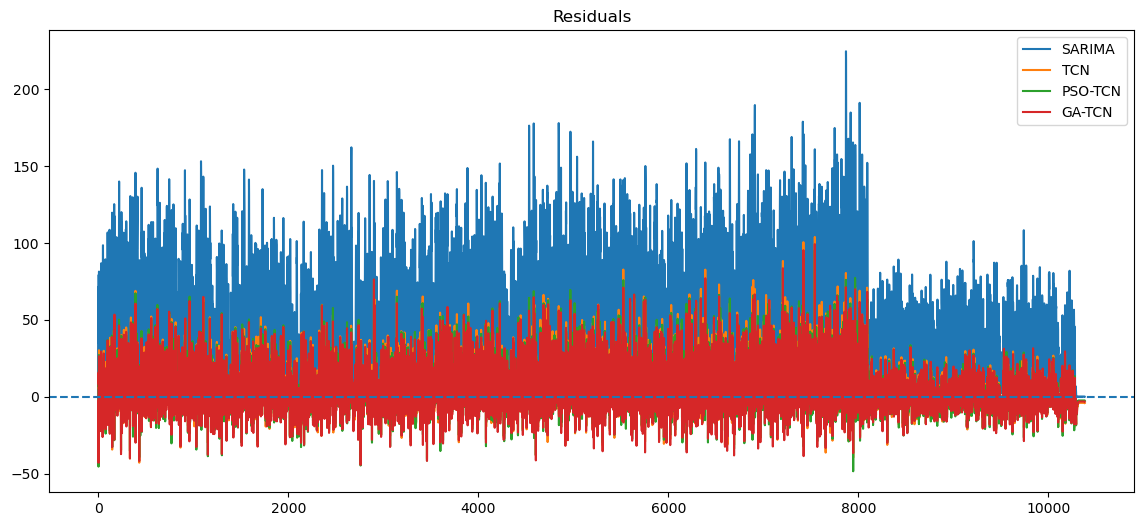

In [15]:
# Residuals
plt.figure(figsize=(14,6))
plt.plot(test.values - sarima_pred.values, label='SARIMA')
plt.plot(y_test_inv.flatten() - tcn_pred.flatten(), label='TCN')
plt.plot(y_test_inv.flatten() - pso_pred.flatten(), label='PSO-TCN')
plt.plot(y_test_inv.flatten() - ga_pred.flatten(), label='GA-TCN')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Residuals")
plt.show()

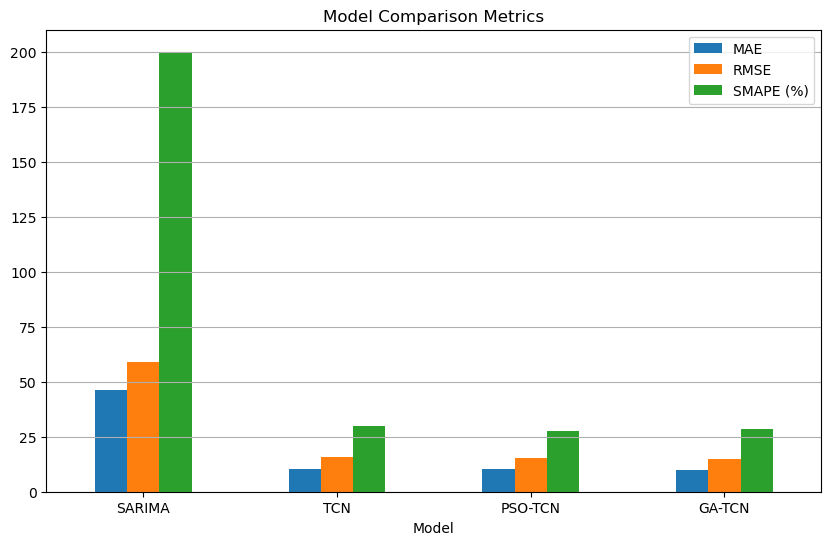

In [16]:
# Metrics comparison
results_df.set_index('Model')[['MAE','RMSE','SMAPE (%)']].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison Metrics")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [17]:
# SAVE FUNCTIONS
output_dir = Path("allModels_fixed_outputs")
output_dir.mkdir(exist_ok=True)

benchmark_timestamps = series.index[train_size:train_size + len(y_test_inv)]

benchmark_export = pd.DataFrame({
    'timestamp': benchmark_timestamps,
    'actual_kwh': y_test_inv.flatten(),
    'tcn_kwh': tcn_pred.flatten(),
    'ga_tcn_kwh': ga_pred.flatten(),
    'pso_tcn_kwh': pso_pred.flatten()
})
benchmark_export.to_csv(output_dir / 'benchmark_forecasts_export.csv', index=False)

results_df.to_csv(output_dir / 'benchmark_metrics.csv', index=False)

params_df = pd.DataFrame([
    {
        'Model': 'PSO-TCN',
        'filters': int(round(best_pos[0])),
        'kernel_size': int(round(best_pos[1])),
        'dropout': float(best_pos[2])
    },
    {
        'Model': 'GA-TCN',
        'filters': int(round(best_ind[0])),
        'kernel_size': int(round(best_ind[1])),
        'dropout': float(best_ind[2])
    }
]).set_index('Model')

params_df.to_csv(output_dir / 'benchmark_optimized_hyperparameters.csv')

fixed_hyperparameters = {
    'pso_tcn': {
        'filters': int(round(best_pos[0])),
        'kernel_size': int(round(best_pos[1])),
        'dropout': float(best_pos[2])
    },
    'ga_tcn': {
        'filters': int(round(best_ind[0])),
        'kernel_size': int(round(best_ind[1])),
        'dropout': float(best_ind[2])
    }
}

with open(output_dir / 'fixed_hyperparameters.json', 'w') as f:
    json.dump(fixed_hyperparameters, f, indent=2)

tcn_model.save(output_dir / 'tcn_model.keras')
pso_model.save(output_dir / 'pso_tcn_model.keras')
ga_model.save(output_dir / 'ga_tcn_model.keras')

print("Saved exports to:", output_dir.resolve())
print(params_df)
print(benchmark_export.head())


Saved exports to: C:\Users\ASUS TUF-Pc\Desktop\Jupyter Notebook\JERWIN\EV_CHARGING_LOAD-main (test)\allModels_fixed_outputs
         filters  kernel_size   dropout
Model                                  
PSO-TCN       97            4  0.195055
GA-TCN       125            5  0.314491
            timestamp  actual_kwh    tcn_kwh  ga_tcn_kwh  pso_tcn_kwh
0 2022-09-28 12:00:00   70.517062  73.226112   73.455093    76.382271
1 2022-09-28 13:00:00   15.869179  61.038254   58.868187    61.339947
2 2022-09-28 14:00:00   37.515513  22.904903   21.721786    25.692003
3 2022-09-28 15:00:00   51.632800  46.234211   43.536968    45.099964
4 2022-09-28 16:00:00   57.257487  47.513222   45.968586    48.049068
